<a href="https://colab.research.google.com/github/saisudhanv/ML-Practice/blob/main/Outlier_detection_using_Percentile_method.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('/content/weight-height.csv')

In [3]:
df.shape

(10000, 3)

In [4]:
df.head()

,Gender,Height,Weight
0,Male,73.847017,241.893563
1,Male,68.781904,162.310473
2,Male,74.110105,212.740856
3,Male,71.730978,220.042470
4,Male,69.881796,206.349801


In [5]:
df['Height'].describe()

,Height
count,10000.000000
mean,66.367560
std,3.847528
min,54.263133
25%,63.505620
50%,66.318070
75%,69.174262
max,78.998742


<Axes: xlabel='Height', ylabel='Density'>

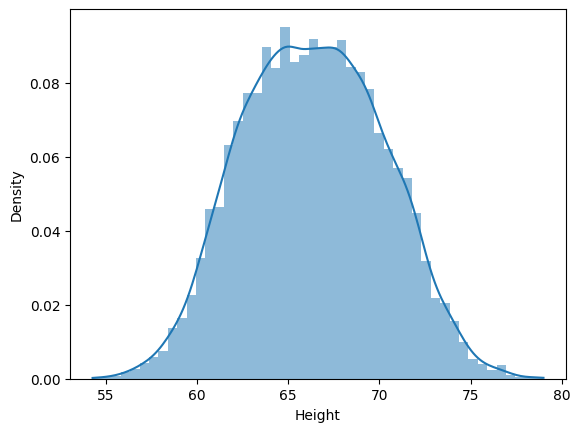

In [11]:
sns.histplot(df['Height'], kde=True, stat='density', linewidth=0) # same as distplot only

<Axes: ylabel='Height'>

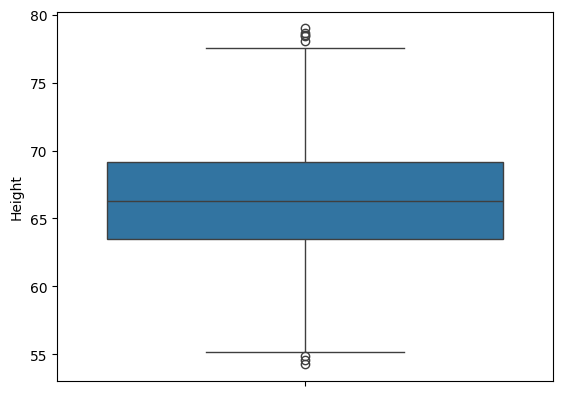

In [13]:
sns.boxplot(df['Height'])

In [14]:
upper_limit = df['Height'].quantile(0.99)
lower_limit = df['Height'].quantile(0.01)

In [16]:
print(upper_limit)

74.7857900583366


In [17]:
print(lower_limit)

58.13441158671655


In [18]:
new_df = df[(df['Height'] <= upper_limit) & (df['Height'] >= lower_limit)]

In [19]:
new_df['Height'].describe()

,Height
count,9800.000000
mean,66.364366
std,3.645075
min,58.134496
25%,63.577162
50%,66.318070
75%,69.119896
max,74.785714


In [20]:
df['Height'].describe()

,Height
count,10000.000000
mean,66.367560
std,3.847528
min,54.263133
25%,63.505620
50%,66.318070
75%,69.174262
max,78.998742


<Axes: xlabel='Height', ylabel='Density'>

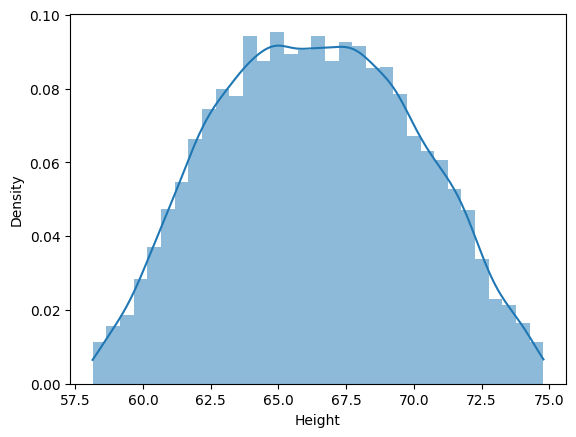

In [21]:
sns.histplot(new_df['Height'], kde=True, stat='density', linewidth=0)

<Axes: ylabel='Height'>

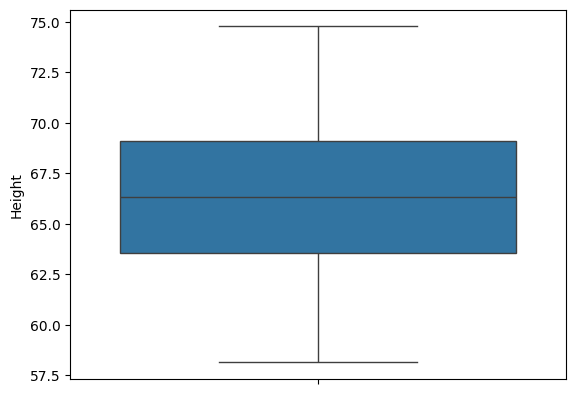

In [22]:
sns.boxplot(new_df['Height'])

**Capping, also known as Winsorization in this percentile**

In [23]:
df['Height'] = np.where(df['Height'] >= upper_limit, upper_limit, np.where(df['Height'] <= lower_limit, lower_limit, df['Height']))

In [24]:
df.shape

(10000, 3)

In [25]:
df['Height'].describe()

,Height
count,10000.000000
mean,66.366281
std,3.795717
min,58.134412
25%,63.505620
50%,66.318070
75%,69.174262
max,74.785790


<Axes: xlabel='Height', ylabel='Density'>

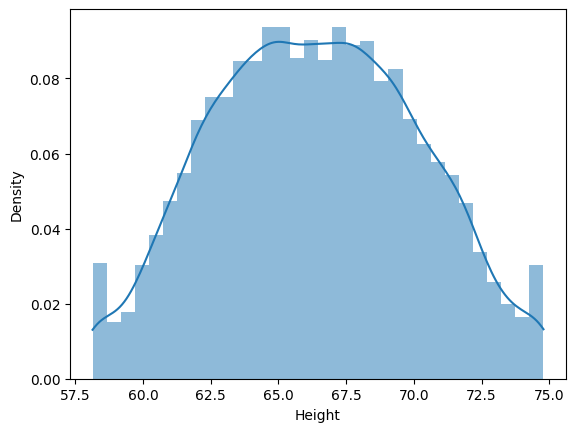

In [26]:
sns.histplot(df['Height'], kde=True, stat='density', linewidth=0)

<Axes: ylabel='Height'>

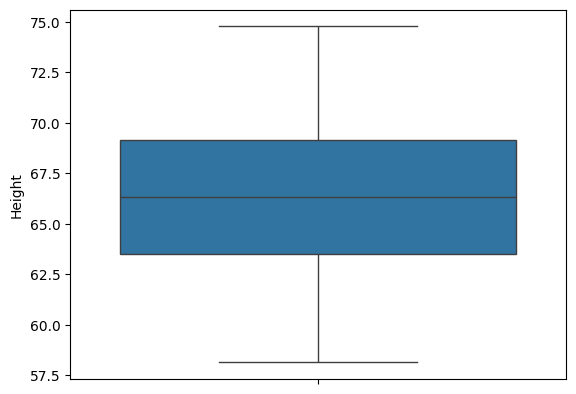

In [27]:
sns.boxplot(df['Height'])